In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'
num_months = 12

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :num_months, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, num_months, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Change is small enough, early break:  49%|████▉     | 244/500 [09:18<09:46,  2.29s/it]                         


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2833164419.215691, 5236483.9894577395, 5381501.158647393, 5980599.337132277, 7095925.093306231, 8240220.19397151, 9233911.5614707, 10000834.868895492, 10483609.704932662, 10813398.11128715, 11058575.773366915, 11240989.852913545, 11381254.94791718, 11491443.604281627, 11576204.124447556, 11644893.8208039, 11703430.471647548, 11754000.91607066, 11796136.205854787, 11830910.594737109, 11860320.02563806, 11885755.336027412, 11908491.883471087, 11929536.431069484, 11949382.935742315, 11967584.44565082, 11983448.210015958, 11996974.936289962, 12008612.6334567, 12018804.098873092, 12027781.294795811, 12035811.60498248, 12043135.715894999, 12049810.566965783, 12055939.36112493, 12061614.352083847, 12066913.220719123, 12071912.65527248, 12076663.277603919, 12081152.46724604, 12085404.017180113, 12089432.412606226, 12093233.421439126, 12096819.168409178, 12100221.197094575, 12103438.735731872, 12106

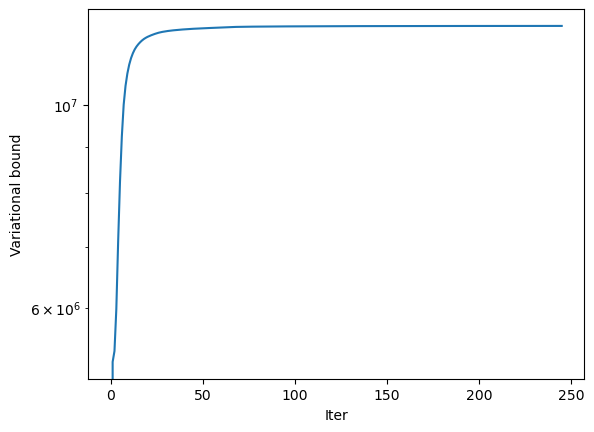

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-6
verbose = True

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

ELBO =  11902364.418, change =  0.00116, time taken =  2.33:   5%|▌         | 26/500 [00:59<18:12,  2.31s/it]


KeyboardInterrupt: 

# Mask with the 1st and 3rd indices masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2744850151.7131953, 6033817.571516187, 6149885.468893116, 6581101.113737382, 7588509.990383484, 8827508.041645808, 10019349.856529148, 10937733.941311618, 11549137.965153161, 11934531.119957212, 12203766.665356146, 12406563.693045916, 12562798.380312584, 12685416.303087568, 12782517.457324952, 12861424.039791718, 12928655.745696763, 12989824.113472303, 13050228.395609954, 13106340.454538884, 13152617.07550612, 13189328.948208168, 13219320.044335427, 13244814.985736357, 13265852.260020893, 13282926.249127802, 13297187.98516259, 13309455.89910479, 13320256.16784731, 13330111.31011009, 13339065.328398805, 13347080.032413455, 13354290.02307585, 13360862.579855897, 13366795.63344772, 13372460.754607879, 13377500.714015478, 13382061.660527643, 13386281.732214116, 13390258.01989919, 13394021.263795106, 13397595.736607421, 13400975.848439625, 13404123.840493761, 13406976.467409797, 13409543.1677245

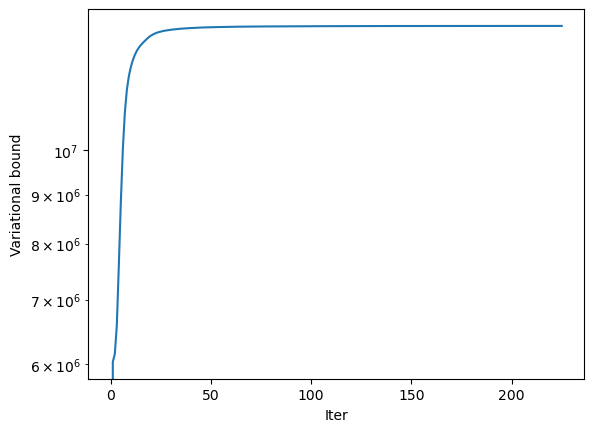

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2941848648.549789, 5946591.816291443, 6038301.032350297, 6364252.341949748, 7351450.397244412, 8824844.195383454, 10104459.012115343, 10973015.03769087, 11566529.680857137, 11996753.97610613, 12309548.317013431, 12524475.741535913, 12673022.947086135, 12781817.109476628, 12863798.301632779, 12927495.83445973, 12979221.270491103, 13022675.467231277, 13059388.717157919, 13091117.504705809, 13119373.78554484, 13145196.599417599, 13169027.127553916, 13190974.839756142, 13211119.615684783, 13229465.33992877, 13246000.121358968, 13260830.748854194, 13274010.16270499, 13285591.379659198, 13295767.94948937, 13304779.537892612, 13312843.570567796, 13320137.336146686, 13326808.333563326, 13332945.601348639, 13338614.134857267, 13343895.650681455, 13348826.800896175, 13353443.728672296, 13357802.173425607, 13361935.522710592, 13365859.382463308, 13369582.245548794, 13373122.889519675, 13376530.6922646

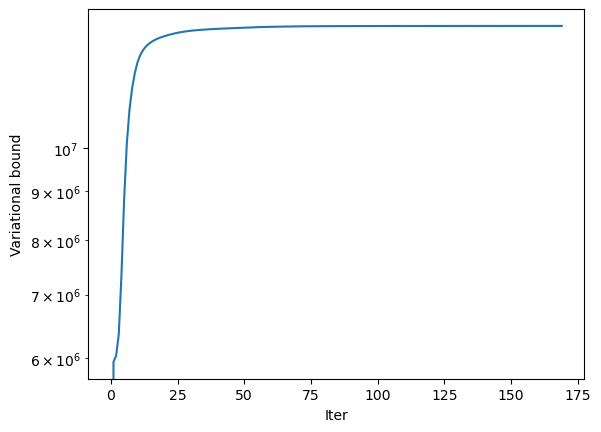

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2934252597.2561016, 8331721.771416186, 8537906.989343377, 9354362.11807755, 11217267.809320528, 13372345.570669802, 15136420.677218959, 16364202.840183329, 17139256.947713062, 17630768.183290802, 17974947.92813893, 18223930.235902574, 18413168.10723821, 18560804.448140465, 18674476.565170303, 18761465.227421913, 18828790.317532483, 18878674.16811275, 18916053.367514264, 18948061.5283718, 18977963.83648729, 19002357.839618202, 19020251.86477628, 19034121.541601114, 19045628.302026927, 19055620.70929993, 19064474.8287474, 19072314.591781847, 19079108.201831765, 19085100.666060638, 19090414.788051598, 19095235.84332218, 19099642.685951773, 19103767.319093607, 19107822.464353755, 19112091.444817398, 19117325.212895595, 19125167.90913399, 19134471.716178842, 19141133.158092115, 19145475.372318346, 19148799.05184988, 19151680.57840041, 19154231.68186147, 19156506.74058575, 19158596.233255774, 191

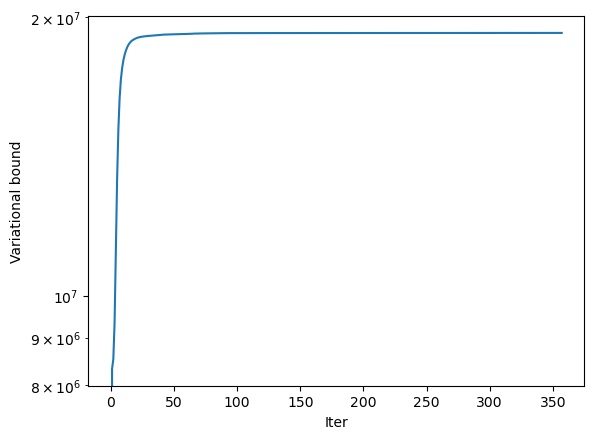

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [ ]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
